##PS- Predicting whether a passenger survived the Titanic disaster based on information about the passenger, such as age, sex, passenger class, fare, family size, and other available features. ##

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('/content/drive/MyDrive/DATASETS/Titanic-Dataset.csv')

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df = df.drop(columns=['Name','PassengerId', 'Cabin','Ticket','Embarked'])


In [11]:
df["Sex"] = df["Sex"].map({
    "male": 1,
    "female": 0
})

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [13]:
df.shape


(891, 7)

In [14]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [15]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0


In [16]:
df[df.isnull().any(axis=1)]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
5,0,3,1,NaN,0,0,8.4583
17,1,2,1,NaN,0,0,13.0000
19,1,3,0,NaN,0,0,7.2250
26,0,3,1,NaN,0,0,7.2250
28,1,3,0,NaN,0,0,7.8792
...,...,...,...,...,...,...,...
859,0,3,1,NaN,0,0,7.2292
863,0,3,0,NaN,8,2,69.5500
868,0,3,1,NaN,0,0,9.5000
878,0,3,1,NaN,0,0,7.8958


In [17]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

In [18]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


 Survival rate

In [19]:
survived_p = df[df['Survived'] == 1].shape[0]
not_survived_p = df[df['Survived'] == 0].shape[0]

rate = (survived_p/df.shape[0])*100
rate  #ovrall survival rate of titanic

38.38383838383838

Checking Male and female survival Rate

In [20]:
male = df[(df['Survived'] == 1) & (df['Sex'] == 1)].shape[0]
female = df[(df['Survived'] == 1) & (df['Sex'] == 0)].shape[0]

total_male = df[df['Sex'] == 1].shape[0]
total_female = df[df['Sex'] == 0].shape[0]

male_rate = round((male/total_male)*100) if total_male > 0 else 0
female_rate = round((female/total_female)*100) if total_female > 0 else 0

print('Total male -',total_male)
print('Total female -',total_female)

print('Male survival rate(Among males only) -',male_rate,'%')
print('Female survival rate(Among females only) -',female_rate,'%')

Total male - 577
Total female - 314
Male survival rate(Among males only) - 19 %
Female survival rate(Among females only) - 74 %


### Survival Rate Visualization

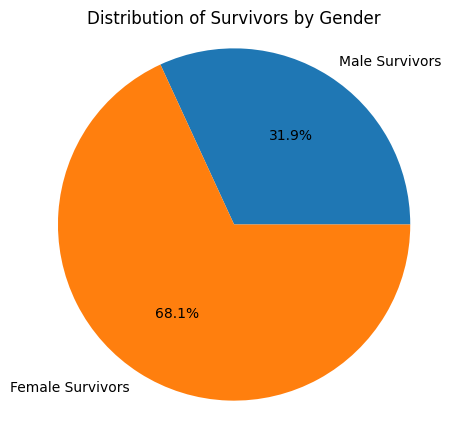

In [21]:

labels = ['Male Survivors', 'Female Survivors']
sizes = [male, female]
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(sizes, labels=labels, autopct='%1.1f%%')
ax.axis('equal')
ax.set_title('Distribution of Survivors by Gender')
plt.show()

Conclusion -- Female has more survival rate then men

## Now analyzing titanicPasswnger Class-wise ##


In [22]:
df['Pclass'].unique()

array([3, 1, 2])

# Classes in titanic is 1ST, 2ND, 3RD

In [23]:
# Survival rate of passengers in 1st class
first_class_survived = df[(df['Survived'] == 1) & (df['Pclass'] == 1)].shape[0]
first_class_total = df[df['Pclass'] == 1].shape[0]

first_class_rate = round((first_class_survived/first_class_total)*100)

# Survival rate of passengers in 2nd class
Second_class_survived = df[(df['Survived'] == 1) & (df['Pclass'] == 2)].shape[0]
Second_class_total = df[df['Pclass'] == 2].shape[0]

Second_class_rate = round((Second_class_survived/Second_class_total)*100)

# Survival rate of passengers in 3rd class
Third_class_survived = df[(df['Survived'] == 1) & (df['Pclass'] == 3)].shape[0]
Third_class_total = df[df['Pclass'] == 3].shape[0]
Third_class_rate = round((Third_class_survived/Third_class_total)*100)

print('Survival rate of passengers in 1st class -',first_class_rate,'%')
print('Survival rate of passengers in 2nd class -',Second_class_rate,'%')
print('Survival rate of passengers in 3rd class -',Third_class_rate,'%')



Survival rate of passengers in 1st class - 63 %
Survival rate of passengers in 2nd class - 47 %
Survival rate of passengers in 3rd class - 24 %


Conclusion-- Survival rate of first class passenger is highest
 1>2>3rd class survival rate

## Relation between gender and passenger class ##

In [24]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean() *100

Sex  Pclass
0    1         96.808511
     2         92.105263
     3         50.000000
1    1         36.885246
     2         15.740741
     3         13.544669
Name: Survived, dtype: float64

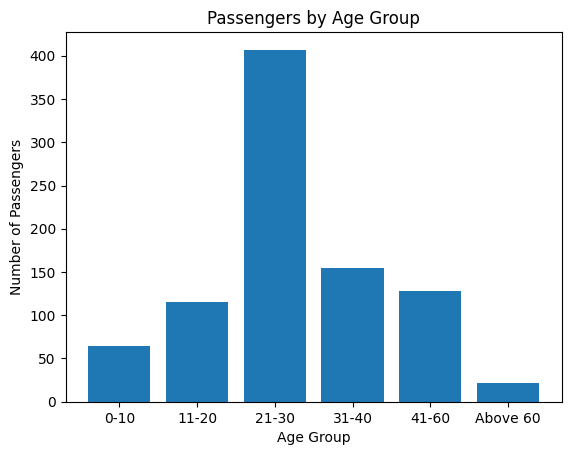

In [25]:


# Create age groups
age_groups = pd.cut(
    df['Age'],
    bins=[0, 10, 20, 30, 40, 60, float('inf')],
    labels=['0-10', '11-20', '21-30', '31-40', '41-60', 'Above 60'],
    include_lowest=True
)

age_counts = age_groups.value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values)

plt.title('Passengers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')

plt.show()

Means maxium passengers in titanic belongs to 20-30 age grp

In [26]:
df.groupby(['Pclass', 'Sex', 'Survived'])['Age'].agg(
    ['count', 'median']
)

count  median
Pclass Sex Survived               
1      0   0             3    25.0
           1            91    33.0
       1   0            77    39.0
           1            45    35.0
2      0   0             6    32.5
           1            70    28.0
       1   0            91    30.0
           1            17     8.0
3      0   0            72    28.0
           1            72    27.0
       1   0           300    28.0
           1            47    27.0

In [27]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [28]:
corr = df.corr(numeric_only=True)

print(corr)

          Survived    Pclass       Sex       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.543351 -0.064910 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000  0.131900 -0.339898  0.083081  0.018443 -0.549500
Sex      -0.543351  0.131900  1.000000  0.081163 -0.114631 -0.245489 -0.182333
Age      -0.064910 -0.339898  0.081163  1.000000 -0.233296 -0.172482  0.096688
SibSp    -0.035322  0.083081 -0.114631 -0.233296  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.245489 -0.172482  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500 -0.182333  0.096688  0.159651  0.216225  1.000000


What we get is -

survival rate increases with decrease in class of passenger (1>2>3). and female survival rate is more than male survival rate.

we have to pridict weather passenger survived or not if survived then 1 elso 0

i think classificaton model works

### Logistic Regression Model Implementation

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 6)
X_test shape: (179, 6)
y_train shape: (712,)
y_test shape: (179,)


Now, let's train the Logistic Regression model.

In [41]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
model.fit(X_train, y_train)

print("trained successfully.")

trained successfully.


Next, we will make predictions on the test set and evaluate the model's performance.

In [39]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy:", accuracy)
print("\nClassification Report:")
print(report)


Accuracy: 0.7932960893854749

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [32]:
predictions = model.predict_proba(X_test.iloc[[112]])
survival_probab = predictions[0, 1] # Probability of survival
print(f"Probability of survival:",survival_probab)

Probability of survival: 0.8947064720606797


### Decision Tree Model

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train, y_train)

print("trained successfully.")

trained successfully.


Next, we will make predictions on the test set and evaluate the Decision Tree model's performance.

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set using the Decision Tree model
dtree_y_pred = dtree_model.predict(X_test)

# Evaluate the Decision Tree model
dtree_accuracy = accuracy_score(y_test, dtree_y_pred)
dtree_report = classification_report(y_test, dtree_y_pred)

print(f"Decision Tree Accuracy: {dtree_accuracy:.2f}")
print("\nDecision Tree Classification Report:")
print(dtree_report)



Decision Tree Accuracy: 0.75

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       105
           1       0.70      0.70      0.70        74

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.75      0.75      0.75       179



### Comparing Logistic Regression and Decision Tree Models

Let's compare the key performance metrics of both models.

In [35]:
print("Logistic Regression:", accuracy)
print("Decision Tree:", dtree_accuracy)

print("\nLogistic Regression Report:")
print(report)

print("\nDecision Tree Report:")
print(dtree_report)

if accuracy > dtree_accuracy:
    print("\nLogistic Regression performed better.")
elif dtree_accuracy > accuracy:
    print("\nDecision Tree performed better.")
else:
    print("\nBoth performed equally.")

Logistic Regression: 0.7932960893854749
Decision Tree: 0.7541899441340782

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


Decision Tree Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       105
           1       0.70      0.70      0.70        74

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.75      0.75      0.75       179


Logistic Regression performed better.


logistic regression perform better becoz our dataset is small. and our dataset is have simpler relation like survival depends upon sex also, fare and as fare is hgh class is high

# Number of Parameters in Logistic Regression
We have 6 params on which our prediction depends so , total params are 7(6+1)